# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load the dataset
df = pd.read_csv('../insurance_raw/insurance.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First Few Rows:")
print(df.head(10))
print("\n" + "="*50)
print("Dataset Info:")
df.info()
print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

Dataset Shape: (1338, 7)

First Few Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-nul

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Unique values per column:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64



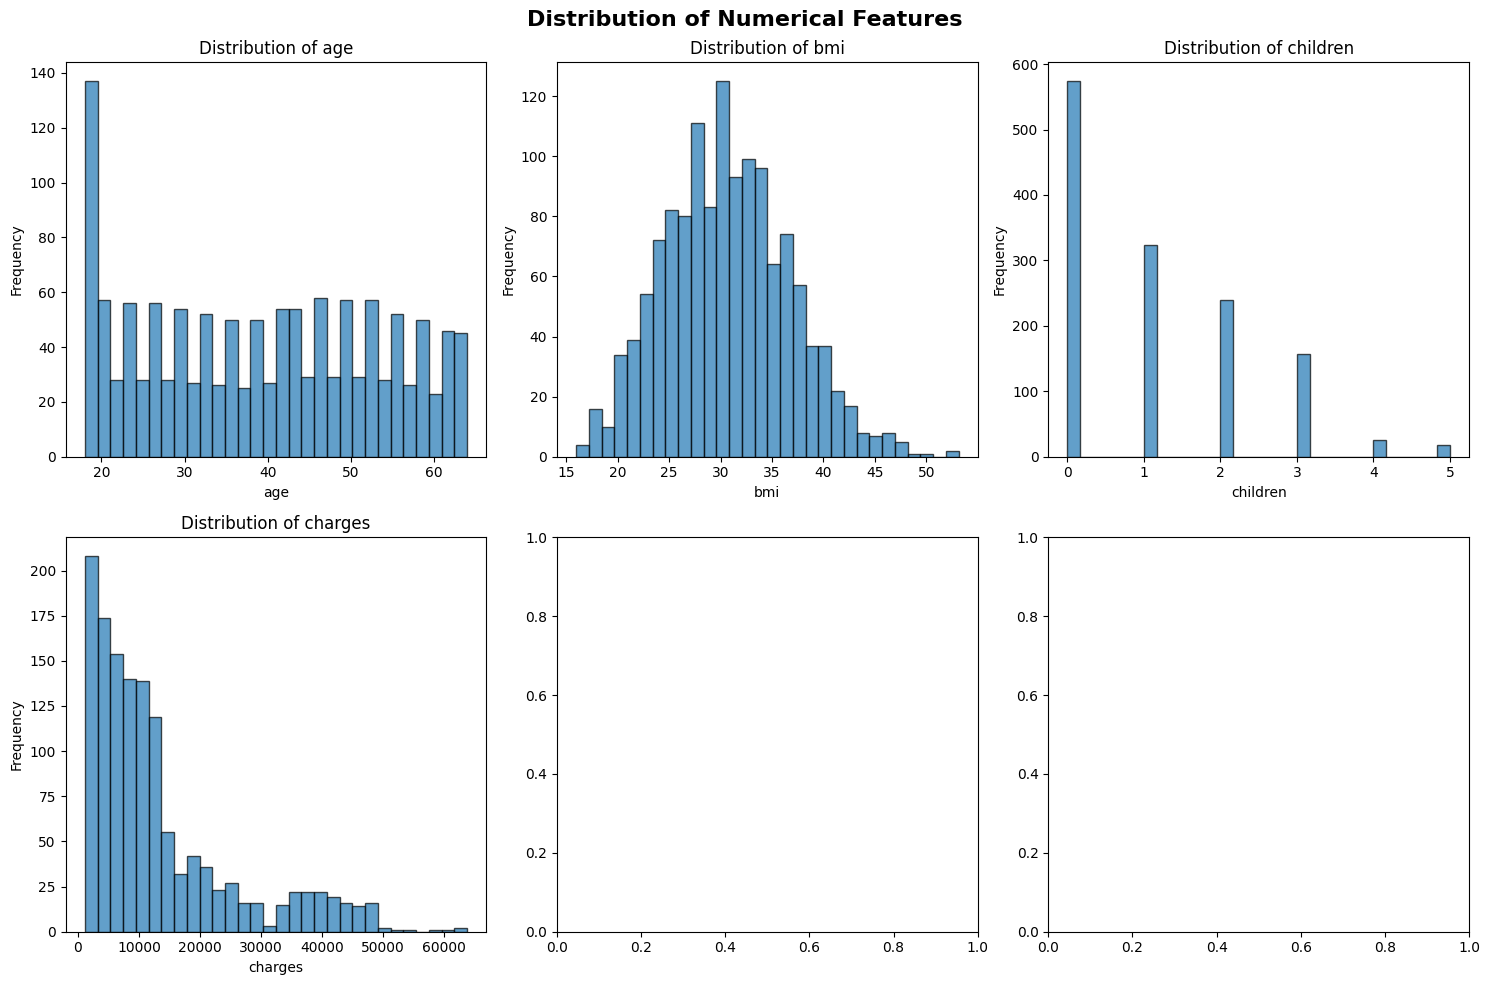


Categorical Features Analysis:

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


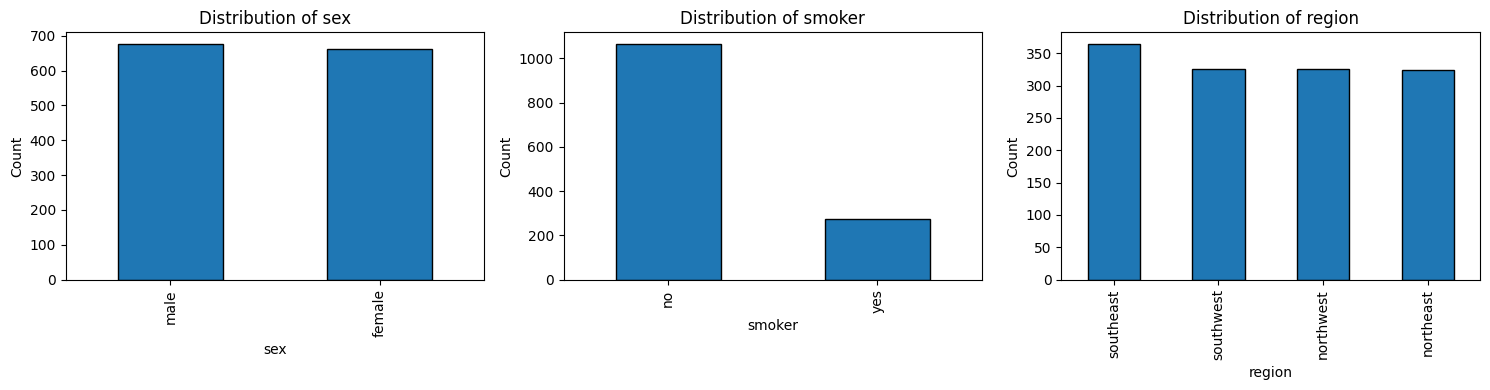


Correlation Matrix:
               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


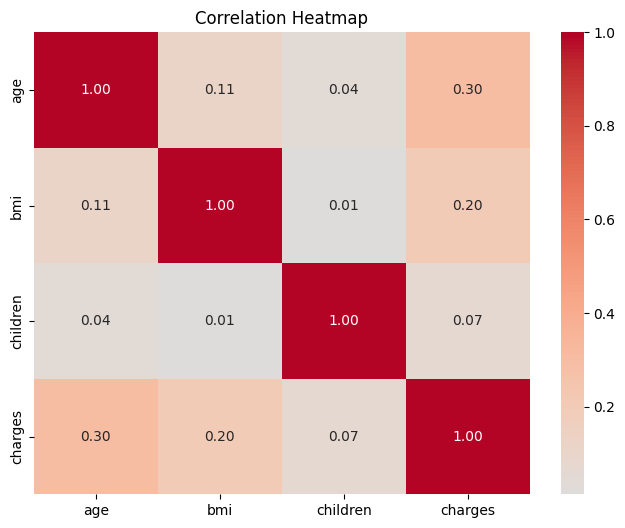

In [3]:
# 4.1 Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# 4.2 Statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50)

# 4.3 Data distribution and relationships
print("Unique values per column:")
print(df.nunique())
print("\n" + "="*50)

# 4.4 Visualize distributions for numerical columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numerical_cols = df.select_dtypes(include=[np.number]).columns
for idx, col in enumerate(numerical_cols):
    ax = axes[idx//3, idx%3]
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 4.5 Categorical features analysis
print("\nCategorical Features Analysis:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    
# 4.6 Visualize categorical distributions
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 4))
if len(categorical_cols) == 1:
    axes = [axes]
    
for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_ylabel('Count')
    
plt.tight_layout()
plt.show()

# 4.7 Correlation analysis
print("\nCorrelation Matrix:")
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 5.1 Create a copy of the dataframe for preprocessing
df_preprocessed = df.copy()

# 5.2 Handle missing values (if any)
print("Missing Values Before Preprocessing:")
print(df_preprocessed.isnull().sum().sum())

# 5.3 Remove duplicates
df_preprocessed = df_preprocessed.drop_duplicates()
print(f"\nDataset shape after removing duplicates: {df_preprocessed.shape}")

# 5.4 Encode categorical variables
print("\nEncoding categorical variables...")
categorical_cols = df_preprocessed.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_preprocessed[col] = le.fit_transform(df_preprocessed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 5.5 Separate features (X) and target (y)
X = df_preprocessed.drop('charges', axis=1)
y = df_preprocessed['charges']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 5.6 Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nData after standardization:")
print(X_scaled_df.describe())

# 5.7 Save preprocessed data
preprocessed_data = X_scaled_df.copy()
preprocessed_data['charges'] = y.values

print(f"\nFinal preprocessed dataset shape: {preprocessed_data.shape}")
print("\nFirst few rows of preprocessed data:")
print(preprocessed_data.head())

Missing Values Before Preprocessing:
0

Dataset shape after removing duplicates: (1337, 7)

Encoding categorical variables...
sex: {'female': np.int64(0), 'male': np.int64(1)}
smoker: {'no': np.int64(0), 'yes': np.int64(1)}
region: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}

Features shape: (1337, 6)
Target shape: (1337,)

Data after standardization:
                age           sex           bmi      children        smoker  \
count  1.337000e+03  1.337000e+03  1.337000e+03  1.337000e+03  1.337000e+03   
mean  -6.643070e-17 -7.440238e-17 -2.285216e-16  3.852980e-17  7.971684e-18   
std    1.000374e+00  1.000374e+00  1.000374e+00  1.000374e+00  1.000374e+00   
min   -1.511647e+00 -1.009771e+00 -2.411119e+00 -9.092342e-01 -5.077017e-01   
25%   -8.705798e-01 -1.009771e+00 -7.171725e-01 -9.092342e-01 -5.077017e-01   
50%   -1.582291e-02  9.903236e-01 -4.320166e-02 -7.944162e-02 -5.077017e-01   
75%    8.389340e-01  9.903236e-0